In [7]:
import torch 
import numpy as np 
import matplotlib.pyplot as plt
from itertools import islice
import json
from tqdm.auto import tqdm


from cryo_sbi.wpa_simulator.cryo_em_simulator import cryo_em_simulator
from cryo_sbi import CryoEmSimulator
from cryo_sbi.inference.models import build_models
import cryo_sbi.utils.estimator_utils as est_utils
from cryo_sbi.inference.priors import get_image_priors, PriorLoader
from cryo_sbi.inference.models.build_models import build_nle_flow_model

/ziggy/build/miniconda3/envs/cryosbi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
models = torch.load("../models.pt")
image_config = "../simulation_parameters.json"
simulation_batch_size = 160
n_workers=4
device="cuda"
BATCH_SIZE = 32
images = torch.load("../images.pt")

/tmp/ipykernel_407661/4222150713.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  models = torch.load("../models.pt")
/tmp/ipykernel_407661/4222150713.py:7: FutureWarning

In [9]:
def evaluate_likelihood_matrix_efficient(
    estimator, 
    images, 
    models, 
    image_batch_size=8,
    model_batch_size=32, 
    device='cuda',
    show_progress=True
):
    """
    More efficient version that batches both images and models.
    
    Args:
        estimator: Trained NLEWithEmbedding model
        images: All images [num_images, H, W]
        models: All conformations [num_models, 3, N]
        image_batch_size: Number of images to process together
        model_batch_size: Number of models to process together
        device: Device to use
        show_progress: Whether to show progress bar
    
    Returns:
        log_likelihood_matrix: [num_images, num_models] 
    """
    estimator.eval()
    estimator.to(device)
    
    # Ensure images have correct shape
    if images.dim() == 2:
        images = images.unsqueeze(0)
    
    num_images = images.shape[0]
    num_models = models.shape[0]
    
    # Initialize result matrix
    log_likelihood_matrix = torch.zeros(num_images, num_models)
    
    # Create progress bar for total iterations
    total_iterations = ((num_images + image_batch_size - 1) // image_batch_size) * \
                       ((num_models + model_batch_size - 1) // model_batch_size)
    
    pbar = tqdm(total=total_iterations, desc="Computing likelihood matrix") if show_progress else None
    
    with torch.no_grad():
        # Iterate over image batches
        for img_start in range(0, num_images, image_batch_size):
            img_end = min(img_start + image_batch_size, num_images)
            batch_images = images[img_start:img_end].to(device)  # [B_img, H, W]
            curr_img_batch = batch_images.shape[0]
            
            # Iterate over model batches
            for model_start in range(0, num_models, model_batch_size):
                model_end = min(model_start + model_batch_size, num_models)
                batch_models = models[model_start:model_end].to(device)  # [B_model, 3, N]
                curr_model_batch = batch_models.shape[0]
                
                # Transpose for GNN: [B_model, 3, N] -> [B_model, N, 3]
                batch_models = batch_models.transpose(1, 2)
                
                # Create all pairs: repeat images and models
                # Each image paired with each model in the batch
                expanded_images = batch_images.unsqueeze(1).repeat(1, curr_model_batch, 1, 1)  
                # [B_img, B_model, H, W]
                expanded_images = expanded_images.reshape(-1, batch_images.shape[1], batch_images.shape[2])  
                # [B_img * B_model, H, W]
                
                expanded_models = batch_models.unsqueeze(0).repeat(curr_img_batch, 1, 1, 1)  
                # [B_img, B_model, N, 3]
                expanded_models = expanded_models.reshape(-1, batch_models.shape[1], batch_models.shape[2])  
                # [B_img * B_model, N, 3]
                
                # Compute log likelihood for all pairs
                log_probs = estimator.forward(expanded_images, expanded_models)  # [B_img * B_model]
                
                # Reshape back to matrix form
                log_probs = log_probs.reshape(curr_img_batch, curr_model_batch)  # [B_img, B_model]
                
                # Store in result matrix
                log_likelihood_matrix[img_start:img_end, model_start:model_end] = log_probs.cpu()
                
                if pbar:
                    pbar.update(1)
    
    if pbar:
        pbar.close()
    
    return log_likelihood_matrix

# Usage:
# Load trained model
estimator = est_utils.load_estimator(
    "../training_parameters_nle.json",
    build_models.build_nle_flow_model,
    "../tutorial_estimator_2.pt",
    device="cuda",
)


log_likelihood_matrix = evaluate_likelihood_matrix_efficient(
    estimator, 
    images,  # [num_images, H, W]
    models,  # [num_models, 3, N]
    image_batch_size=8,   # Process 8 images at once
    model_batch_size=32,  # Process 32 models at once
    device='cuda',
    show_progress=True
)


/ziggy/cryoSBI/src/cryo_sbi/utils/estimator_utils.py:151: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(estimator_path, map_location=torch.device(device))
Computi

tensor([693.4774, 693.5387, 693.5019, 693.5350, 693.5248, 693.5253, 693.5128,
        693.5167, 693.5334, 693.5162, 693.5291, 693.5341, 693.5295, 693.5361,
        693.5436, 693.5442, 693.5492, 693.5499, 693.5454, 693.5367])


In [10]:
np.save('log_prob.npy', log_likelihood_matrix.numpy())


In [14]:
log = np.load('log_prob.npy')
print(log.shape)

(5000, 20)


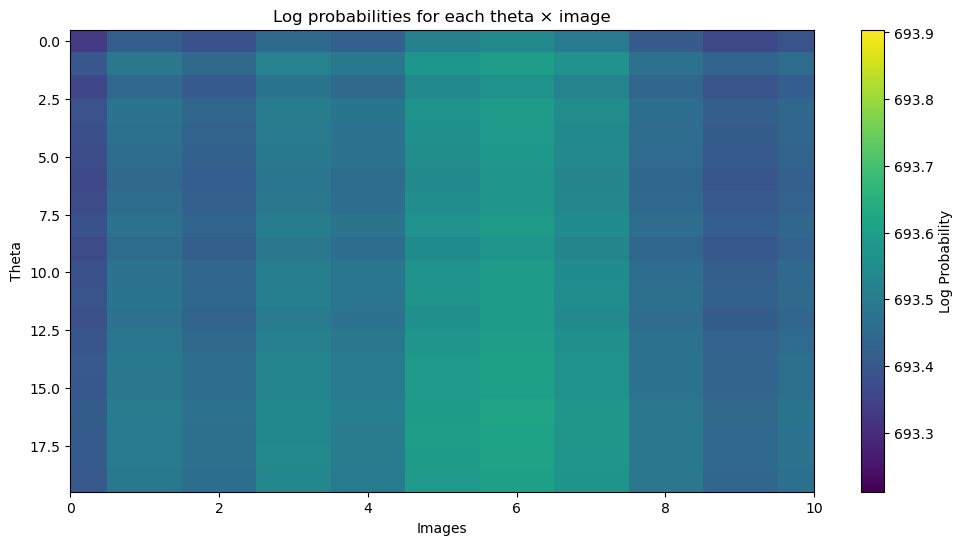

In [16]:
plt.figure(figsize=(12, 6))
plt.imshow(log.transpose(), aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta')
plt.title('Log probabilities for each theta × image')
plt.xlim(0,10)
plt.show()

In [13]:
print(log[:,0])

[693.33484 693.42004 693.3849  ... 693.57935 693.5573  693.56665]
